In [31]:
import pandas as pd
import numpy as np
import json
import glob
import csv
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

import spacy
from nltk.corpus import stopwords
import pyLDAvis
import pyLDAvis.gensim
import pyLDAvis.gensim_models

In [32]:
def load_data(file):
    with open (file, "r", encoding="utf-8") as f:
        data = json.load(f)
    return (data)

def write_data(file, data):
    with open (file, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

In [33]:
stopwords = stopwords.words("english")
stopwords.append("be")
print(stopwords)

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [37]:
# Load the JSON data from the file
with open("combined_file.json", "r") as file:
    data = json.load(file)

# Get the keys of the JSON object
fields = data.values()

# Print the fields
print(fields)


AttributeError: 'list' object has no attribute 'values'

In [38]:
data = load_data("combined_file.json")
print (data[0][0:90])
print (data[1][0:90])

["good,evening,hello,how,are,you,it's,great,to,be,back,in,india,i've,been,traveling,the,world,a,lot,this,year,so,it's,good,to,be,back,in,bangalore,where,we,have,no,need,for,small,talk,not,a,single,the,best,thing,about,india,is,you,can,look,someone,you,don't,know,in,the,eyes,and,just,fucking,walk,right,past,them,you,don't,deserve,interaction,not,so,the,case,in,other,countries,i,was,in,the,north,america,getting,a,coffee,which,is,the,national,sport,and,it's,a,whole,when,you,walk,in,you,have,to,first,say,hi,how,are,you,i'm,good,thanks,how,are,you,i'm,good,as,well,hot,outside,isn't,it,it,is,hot,then,you,can,begin,speaking,in,this,much,time,the,population,of,india,has,doubled,don't,do,small,talk,we,do,only,big,talk,talk,to,an,aunty,hello,beta,hello,what,is,your,yearly,salary,haven't,been,away,that,long,came,back,everything's,different,all,the,airports,now,are,silent,airports,yeah,they,don't,make,any,announcements,at,the,airport,anymore,reason,i,know,that,is,because,they,made,an,announcement,

In [39]:
def lemmatization(texts, allowed_postages=["NOUN", "ADJ", "VERB", "ADV"]):
    nlp = nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    texts_out = []
    for text in data:
        doc = nlp(text)
        new_text = []
        for token in doc:
            if token.pos_ in allowed_postages:
                new_text.append(token.lemma_)
        final = " ".join(new_text)
        texts_out.append(final)
    return (texts_out)

lemmatized_texts = lemmatization(data)
print (lemmatized_texts[0][0:150])

ValueError: [E1041] Expected a string, Doc, or bytes as input, but got: <class 'list'>

In [ ]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download()

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['let', 'say', 'go', 'guy', 'get', 'think', 'make', 'thing', 'know', 'come', 'look', 'see', 'tell', 'take', 'put', 'bro'])
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]

In [ ]:
def gen_words(data):
    final = []
    for text in data:
        new = gensim.utils.simple_preprocess(text, deacc=True)
        final.append(new)
    return (final)

data_words = gen_words(lemmatized_texts)

print (data_words[0][0:20])
print (data_words[1][0:20])

In [ ]:
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

In [40]:
#BIGRAMS AND TRIGRAMS
bigram_phrases = gensim.models.Phrases(data_words, min_count=5, threshold=200)
trigram_phrases = gensim.models.Phrases(bigram_phrases[data_words], threshold=100)

bigram = gensim.models.phrases.Phraser(bigram_phrases)
trigram = gensim.models.phrases.Phraser(trigram_phrases)

def make_bigrams(texts):
    return([bigram[doc] for doc in texts])

def make_trigrams(texts):
    return ([trigram[bigram[doc]] for doc in texts])

data_bigrams = make_bigrams(data_words)
data_bigrams_trigrams = make_trigrams(data_bigrams)

print (data_bigrams_trigrams[0])

['good', 'evening', 'great', 'back', 'travel', 'world', 'lot', 'year', 'good', 'back', 'need', 'small', 'talk', 'good', 'eye', 'walk', 'right', 'deserve', 'interaction', 'case', 'country', 'coffee', 'national', 'sport', 'whole', 'walk', 'first', 'good', 'thank', 'good', 'well', 'hot', 'outside', 'hot', 'begin', 'speak', 'much', 'time', 'population', 'double', 'small', 'talk', 'big', 'talk', 'talk', 'aunty', 'beta', 'yearly', 'salary', 'away', 'long', 'back', 'different', 'airport', 'silent', 'airport', 'announcement', 'airport', 'anymore', 'reason', 'announcement', 'announcement', 'lady', 'gentleman', 'want', 'happen', 'minute', 'prevent', 'noise', 'pollution', 'snicker', 'big', 'problem', 'country', 'run', 'water', 'least', 'die', 'quietly', 'prevent', 'noise', 'pollution', 'announcement', 'people', 'still', 'catch', 'flight', 'send', 'airline', 'personally', 'scream', 'face', 'noise', 'pollution', 'prevent', 'simple', 'announcement', 'passenger', 'report', 'gate', 'number', 'walk', '

In [41]:
# TF-IDF REMOVAL
from gensim.models import TfidfModel

id2word = corpora.Dictionary(data_bigrams_trigrams)

texts = data_bigrams_trigrams

corpus = [id2word.doc2bow(text) for text in texts]
print (corpus[0][0:20])

tfidf = TfidfModel(corpus, id2word=id2word)

low_value = 0.03
words = []
words_missing_in_tfidf = []
for i in range (0, len(corpus)):
    bow = corpus[i]
    low_value_words = [] # reinitialization to be safe, you can skip this
    tfidf_ids = [id for id, value in bow]
    bow_ids = [id for id, value in bow]
    low_value_words = [id for id, value in tfidf[bow] if value < low_value]
    drops = low_value_words+words_missing_in_tfidf
    for item in drops:
        words.append(id2word[item])
    words_missing_in_tfidf = [id for id in bow_ids if id not in tfidf_ids] # the words with tf-idf score 0 will be missing
    
    new_bow = [b for b in bow if b[0] not in low_value_words and b[0] not in words_missing_in_tfidf]
    corpus[i] = new_bow
    

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 8), (5, 1), (6, 1), (7, 3), (8, 1), (9, 8), (10, 1), (11, 2), (12, 1), (13, 1), (14, 1), (15, 2), (16, 1), (17, 1), (18, 2), (19, 3)]


In [42]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, 
                                           id2word=id2word,
                                           num_topics=4,
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha="auto")

In [43]:
lda_model.print_topics()

[(0,
  '0.017*"time" + 0.015*"letter" + 0.012*"write" + 0.012*"goal" + 0.012*"play" + 0.011*"feel" + 0.011*"people" + 0.011*"good" + 0.010*"friend" + 0.009*"right"'),
 (1,
  '0.001*"right" + 0.001*"people" + 0.001*"man" + 0.001*"shit" + 0.001*"time" + 0.001*"feel" + 0.001*"good" + 0.001*"woman" + 0.001*"give" + 0.001*"year"'),
 (2,
  '0.014*"nice" + 0.012*"mom" + 0.009*"woman" + 0.009*"maid" + 0.008*"want" + 0.008*"people" + 0.008*"even" + 0.008*"house" + 0.007*"shit" + 0.007*"sit"'),
 (3,
  '0.018*"shit" + 0.014*"man" + 0.013*"right" + 0.012*"year" + 0.011*"indian" + 0.010*"world" + 0.009*"good" + 0.009*"believe" + 0.009*"people" + 0.009*"story"')]

In [45]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="mmds", R=10)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.112556 -0.074029       1        1  34.741271
3     -0.078752  0.095524       2        1  34.219722
2      0.064496 -0.104733       3        1  31.014827
1      0.126811  0.083239       4        1   0.024180, topic_info=        Term       Freq      Total Category  logprob  loglift
511     nice  23.000000  23.000000  Default  10.0000  10.0000
324     goal  23.000000  23.000000  Default   9.0000   9.0000
426   letter  32.000000  32.000000  Default   8.0000   8.0000
207      dog  17.000000  17.000000  Default   7.0000   7.0000
1747    maid  15.000000  15.000000  Default   6.0000   6.0000
...      ...        ...        ...      ...      ...      ...
805     time   0.000864  55.162321   Topic4  -7.3149  -2.7366
1539   woman   0.000839  30.356828   Topic4  -7.3449  -2.1693
325     good   0.000857  47.187462   Topic4  -7.3232  -2.5887
321     give   0.000830  34.450747   Topic4  -7.3553  -2.3062
890     year   0.000826  31.433025   Topic4  -7.3601  -2.2193

[89 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
942       3  0.958754    awesome
62        2  0.939880       ball
63        1  0.992018       band
951       2  0.974012  beautiful
955       2  0.959245       beef
...     ...       ...        ...
886       1  0.728417      write
886       2  0.253362      write
890       1  0.222696       year
890       2  0.699901       year
890       3  0.095441       year

[100 rows x 3 columns], R=10, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 3, 2])

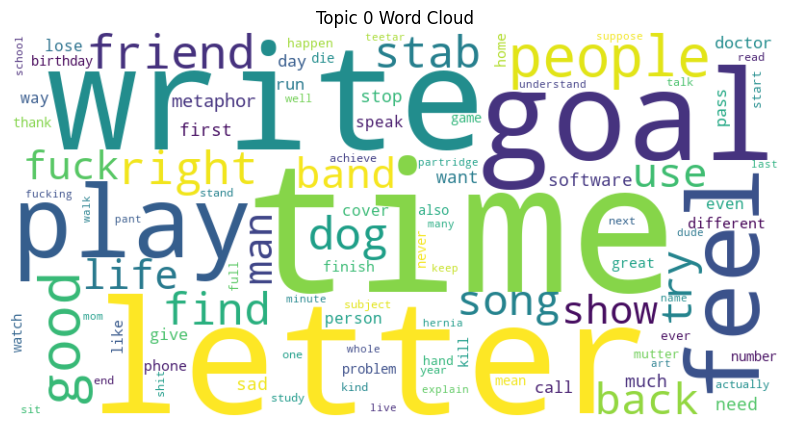

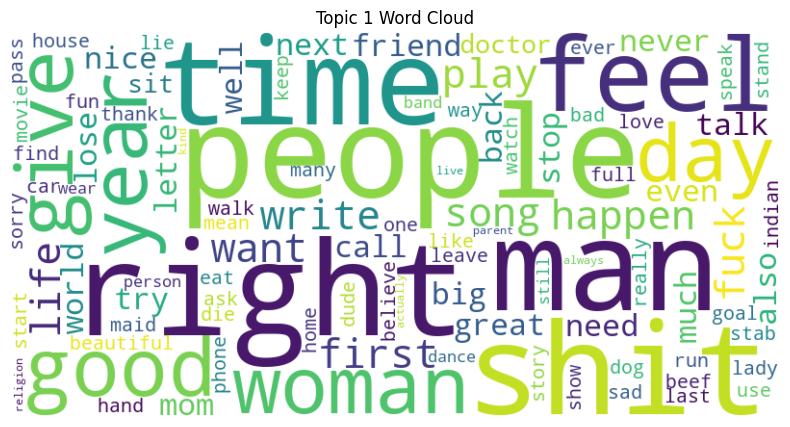

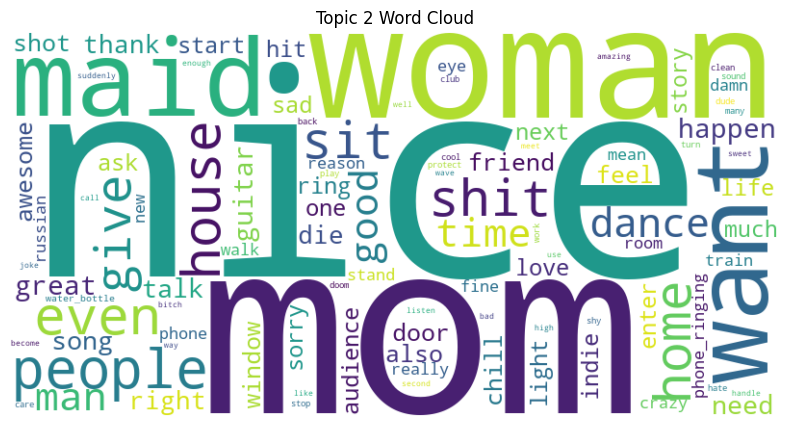

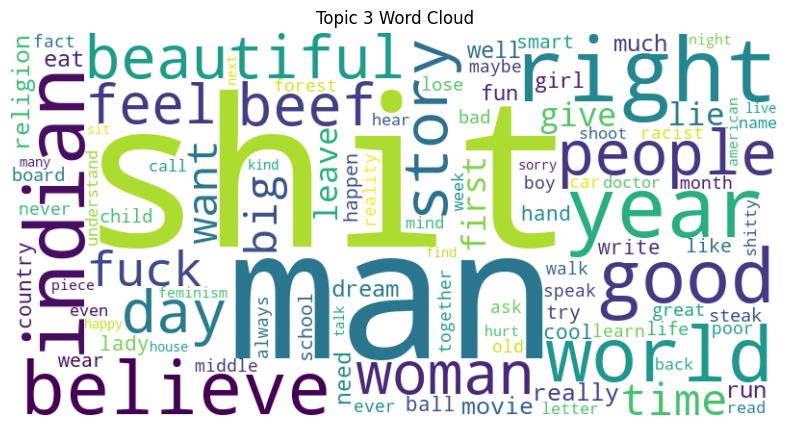

In [21]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def generate_wordcloud(lda_model, topic_id, num_words=100):
    # Get the topic-term distribution
    topic_terms = lda_model.show_topic(topic_id, topn=num_words)
    
    # Generate a word cloud
    wordcloud_dict = {term: prob for term, prob in topic_terms}
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(wordcloud_dict)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic_id} Word Cloud')
    plt.show()

# Assuming lda_model is your trained LDA model
num_topics = lda_model.num_topics
for topic_id in range(num_topics):
    generate_wordcloud(lda_model, topic_id)

In [25]:
import json
import gensim
import pyLDAvis.gensim

# Define a simple preprocessing function
def preprocess(text):
    # Tokenize the text and convert to lowercase
    return text.lower().split()

# Load the JSON file
with open('combined_transcripts.json', 'r') as file:
    data = json.load(file)

# Assuming lda_model is your trained LDA model
num_topics = lda_model.num_topics

# Assuming you have id2word dictionary for the LDA model
id2word = lda_model.id2word

# Iterate over each index (0 to 2) in the JSON data
for index, content in enumerate(data):
    # Preprocess the content if needed
    # Assuming your content is a list of strings (documents)
    corpus = [preprocess(doc) for doc in content]
    
    # Generate topics for the current content
    topics = lda_model.show_topics(num_topics=num_topics, formatted=False)
    
    # Extract top words for each topic
    topic_terms = [[term for term, prob in topic] for topic_id, topic in topics]
    
    # Generate topics for the current content
    vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="mmds", R=10, sort_topics=False, topic_order=topic_terms)
    
    # Visualize or save the topics for the current content
    pyLDAvis.save_html(vis, f'topics_content_{index}.html')  # Save HTML file with visualization


ValueError: not enough values to unpack (expected 2, got 1)